sun mapping stuff by tachyon

In [1]:
try:
    import fermipy
    print("Ready.")
except ImportError:
    print("Fermipy is not installed. Please install it to use this script.")

Ready.


imported stuff/setup

In [2]:
import pandas as pd
from astropy.time import Time
from astropy.coordinates import get_sun
import astropy.units as u
from fermipy.gtanalysis import GTAnalysis
import os
from pathlib import Path
from astropy.io import fits 


i want to work on how to get the correct solar flares myself from the fermi lat data query

In [3]:

#read the original csv file from the extra stuff folder 
df = pd.read_csv("extrastuff/LocalizationTable.csv")

#buffer for time before and after events
buffer = 10

print("Fermi LAT Data Query Parameters:")

#get the information from the csv and convert to gregorian
for index, row in df.iterrows():
    flarename = str(row["Indv Name"])
    date_time_i = str(row["Date and Time"])

    date_time_f = date_time_i.split(' ')[0]
    timerange = date_time_i.replace(date_time_f, '').strip()
    starttime, endtime = timerange.split(' - ')

    start_utc = f"{date_time_f}T{starttime.strip()}:00"
    end_utc = f"{date_time_f}T{endtime.strip()}:00"

    #make astropy time objects
    t_start = Time(start_utc, format='isot', scale='utc')
    t_end = Time(end_utc, format='isot', scale='utc')

    #add the buffer
    t_start_buffered = t_start - buffer * u.second
    t_end_buffered = t_end + buffer * u.second

    #format for gregorian input to fermi site
    fermi_start = t_start_buffered.strftime('%Y-%m-%d %H:%M:%S')
    fermi_end = t_end_buffered.strftime('%Y-%m-%d %H:%M:%S')

    #get sun coords at start time
    sun_position = get_sun(t_start)
    ra = round(sun_position.ra.deg, 3)
    dec = round(sun_position.dec.deg, 3)

    #print the parameters for the query
    print(f" --- Flare Name: {flarename} --- ")
    print(f"Sun Coordinates      :{ra}, {dec}")
    print(f"Coordinate System       :J2000")
    print(f"Search Radius           :20 degrees")
    print(f"Obs. Dates              :{fermi_start},{fermi_end}")
    print(f"Time System             :Gregorian")
    print(f"Energy Range            :100, 100000")
    print(f"LAT Data Type            :Photon")
    print(f"Always Check Spacecraft Data.")

Fermi LAT Data Query Parameters:
 --- Flare Name: 110906925 --- 
Sun Coordinates      :165.08, 6.369
Coordinate System       :J2000
Search Radius           :20 degrees
Obs. Dates              :2011-09-06 22:10:50,2011-09-06 22:47:10
Time System             :Gregorian
Energy Range            :100, 100000
LAT Data Type            :Photon
Always Check Spacecraft Data.
 --- Flare Name: 120307028 --- 
Sun Coordinates      :347.738, -5.261
Coordinate System       :J2000
Search Radius           :20 degrees
Obs. Dates              :2012-03-07 00:39:50,2012-03-07 01:20:10
Time System             :Gregorian
Energy Range            :100, 100000
LAT Data Type            :Photon
Always Check Spacecraft Data.
 --- Flare Name: 120307161 --- 
Sun Coordinates      :347.861, -5.209
Coordinate System       :J2000
Search Radius           :20 degrees
Obs. Dates              :2012-03-07 03:50:50,2012-03-07 04:31:10
Time System             :Gregorian
Energy Range            :100, 100000
LAT Data Type        

Now, I want to start making a csv that puts together the fits files into a "raw" csv to start from. 

In [4]:
#set raw data directory and output csv path
raw_dir = Path("data/fits/raw")
out_csv = Path("data/fits/raw/rawdata.csv")

#begin input for loop to read the fits files get the right info 
rows = []
for fp in sorted(raw_dir.rglob("*")):
    if not fp.is_file():
        continue
    if not (fp.name.lower().endswith(".fits") or fp.name.lower().endswith("fits.gz")):
        continue

#setup recording
    record = {
        "filename": fp.name,
        "filepath": str(fp), 
        "filesize": fp.stat().st_size, 
        "date_obs": None, 
        "date_end": None, 
        "ra": None, 
        "dec": None, 
        "instrument": None,
        "telescope": None, 
    }
#i would include object and flare class but this is not included 

    #read the fits file and extract the header
    try:
        with fits.open(fp) as hdul:
            header = hdul[0].header
            record["date_obs"] = header.get("DATE-OBS")
            record["date_end"] = header.get("DATE-END")
            record["ra"] = header.get("RA")
            record["dec"] = header.get("DEC")
            record["instrument"] = header.get("INSTRUME")
            record["telescope"] = header.get("TELESCOP")
    except Exception as e:
        record["error"] = str(e)
    
    #append the record to the list
    rows.append(record)

#create a dataframe from the records and write to csv
df_raw = pd.DataFrame(rows)
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_raw.to_csv(out_csv, index=False)

#print the number of records written and show the first few rows of the dataframe
print(f"Wrote {len(df_raw)} records to {out_csv}")
df_raw.head()



Wrote 12 records to data/fits/raw/rawdata.csv


,filename,filepath,filesize,date_obs,date_end,ra,dec,instrument,telescope
0,L2603311255089B9590BF64_PH00.fits,data/fits/raw/L2603311255089B9590BF64_PH00.fits,528920,2014-09-01T10:50:00.0000,2014-09-01T11:30:00.0000,None,None,LAT,GLAST
1,L2603311255089B9590BF64_SC00.fits,data/fits/raw/L2603311255089B9590BF64_SC00.fits,37813,2014-09-01T10:50:00.0000,2014-09-01T11:30:00.0000,None,None,LAT,GLAST
2,L2604021201389C9590BF63_PH00.fits,data/fits/raw/L2604021201389C9590BF63_PH00.fits,149760,2011-09-06T22:10:50.0000,2011-09-06T22:47:10.0000,None,None,LAT,GLAST
3,L2604021201389C9590BF63_SC00.fits,data/fits/raw/L2604021201389C9590BF63_SC00.fits,31680,2011-09-06T22:10:50.0000,2011-09-06T22:47:10.0000,None,None,LAT,GLAST
4,L2604021204279C9590BF75_PH00.fits,data/fits/raw/L2604021204279C9590BF75_PH00.fits,1301760,2012-03-07T00:39:49.9999,2012-03-07T01:20:10.0000,None,None,LAT,GLAST


FORGET ALL THAT STUFF
i did it all using scripts that completed the tasks individually 
i'll describe the process in a moment, but for now, i need to plot stuff

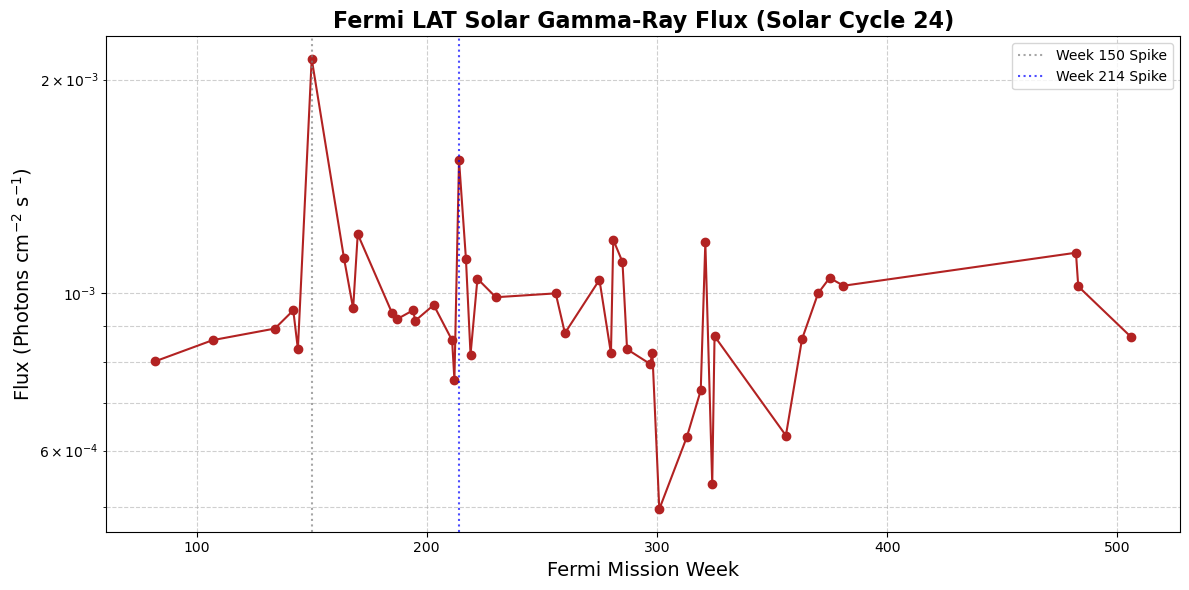

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('solar_cycle_flux.csv')

# Sort by week just in case the batch script processed them out of order
df = df.sort_values('week')

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df['week'], df['flux'], marker='o', linestyle='-', color='firebrick', linewidth=1.5, markersize=6)

# Formatting
plt.title('Fermi LAT Solar Gamma-Ray Flux (Solar Cycle 24)', fontsize=16, fontweight='bold')
plt.xlabel('Fermi Mission Week', fontsize=14)
plt.ylabel('Flux (Photons cm$^{-2}$ s$^{-1}$)', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.yscale('log') # Log scale is usually best for flare flux!

# Highlight the peaks we noticed in the terminal
plt.axvline(x=150, color='grey', linestyle=':', alpha=0.7, label='Week 150 Spike')
plt.axvline(x=214, color='blue', linestyle=':', alpha=0.7, label='Week 214 Spike')

plt.legend()
plt.tight_layout()
plt.show()

troubleshooting plot: raw photons vs livetime exposures

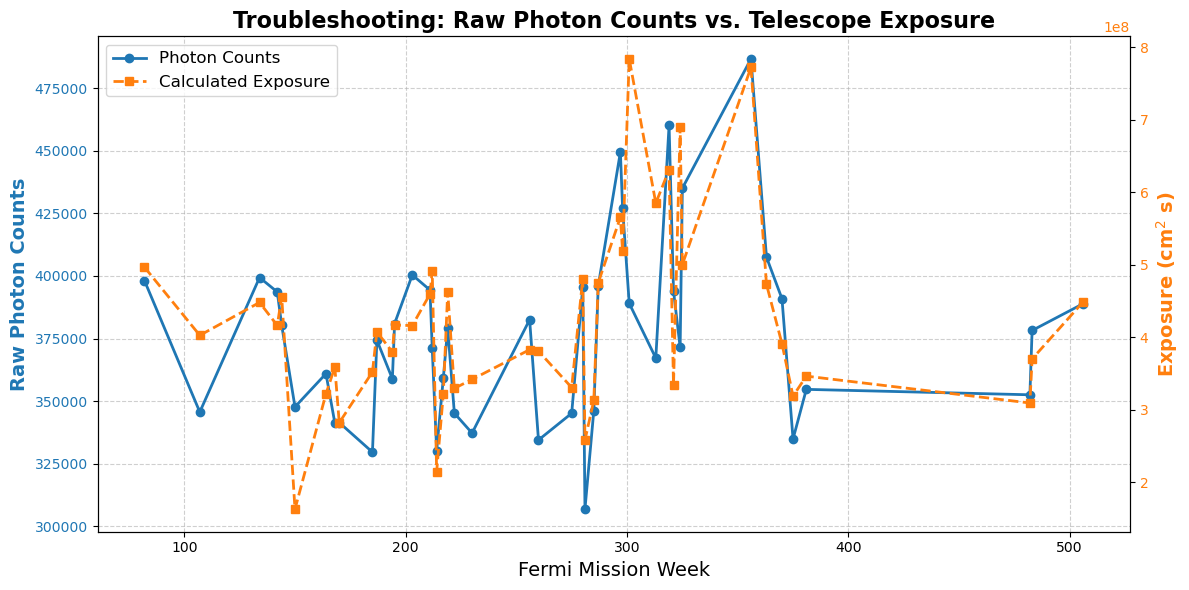

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Load and sort the data
df = pd.read_csv('solar_cycle_flux.csv')
df = df.sort_values('week')

#Set up the figure and the first axis (Left Y-Axis for Counts)
fig, ax1 = plt.subplots(figsize=(12, 6))

#Plot Raw Counts
color1 = 'tab:blue'
ax1.set_xlabel('Fermi Mission Week', fontsize=14)
ax1.set_ylabel('Raw Photon Counts', color=color1, fontsize=14, fontweight='bold')
line1 = ax1.plot(df['week'], df['counts'], color=color1, marker='o', linestyle='-', linewidth=2, label='Photon Counts')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

#Set up the second axis (Right Y-Axis for Exposure)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

#Plot Exposure
color2 = 'tab:orange'
ax2.set_ylabel('Exposure (cm$^2$ s)', color=color2, fontsize=14, fontweight='bold')
line2 = ax2.plot(df['week'], df['exposure'], color=color2, marker='s', linestyle='--', linewidth=2, label='Calculated Exposure')
ax2.tick_params(axis='y', labelcolor=color2)

#Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=12)

#Title and formatting
plt.title('Raw Photon Counts vs. Telescope Exposure', fontsize=16, fontweight='bold')
fig.tight_layout()  # ensures nothing gets cut off

#Show the plot
plt.show()

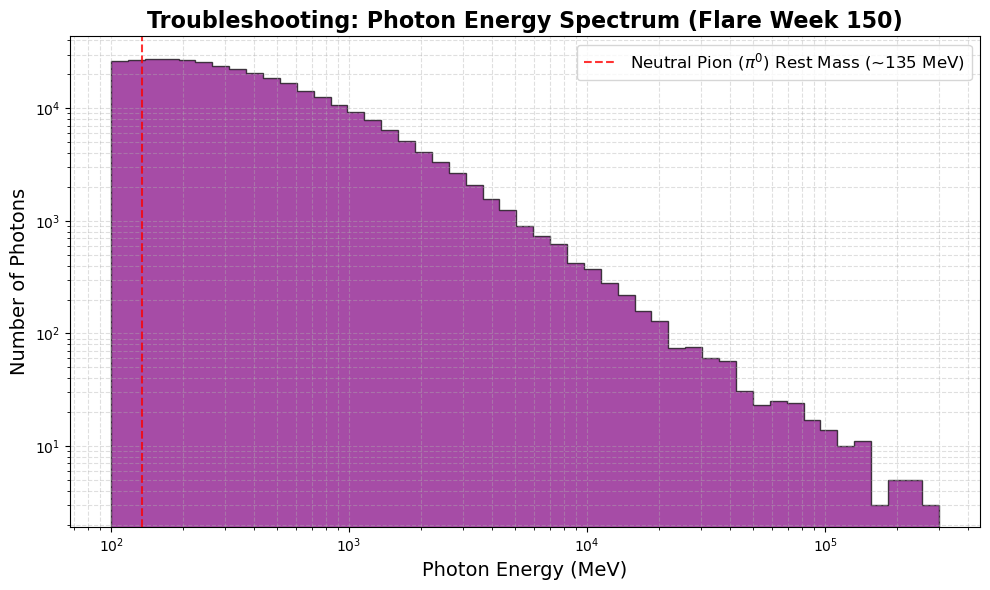

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os

#Define the specific flare week to analyze
week_to_analyze = '150'
photon_file = f'./flsf_photons/filtered_photons_w{week_to_analyze}.fits'

#Failsafe check
if not os.path.exists(photon_file):
    print(f"Error: Could not find {photon_file}. Make sure you are in the right directory.")
else:
    #Extract the Energy data from the FITS file
    with fits.open(photon_file) as hdul:
        # Fermi stores energy in MeV
        energies = hdul['EVENTS'].data['ENERGY']
    
    #Set up the logarithmic bins (100 MeV to 300,000 MeV / 300 GeV)
    min_energy = 100
    max_energy = 300000
    bins = np.logspace(np.log10(min_energy), np.log10(max_energy), 50)
    
    #Create the plot
    plt.figure(figsize=(10, 6))
    
    #Plot the histogram (Merged into one line to prevent copy-paste errors!)
    counts, bin_edges, _ = plt.hist(energies, bins=bins, histtype='stepfilled', color='purple', alpha=0.7, edgecolor='black')
    
    #Formatting the axes to highlight the physics
    plt.xscale('log')
    plt.yscale('log')
    
    plt.title(f'Photon Energy Spectrum (Flare Week {week_to_analyze})', fontsize=16, fontweight='bold')
    plt.xlabel('Photon Energy (MeV)', fontsize=14)
    plt.ylabel('Number of Photons', fontsize=14)
    
    #Add a vertical line around ~135 MeV (rest mass of neutral pion) 
    plt.axvline(x=135, color='red', linestyle='--', alpha=0.8, label='Neutral Pion ($\\pi^0$) Rest Mass (~135 MeV)')
    
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    #Show the plot
    plt.show()

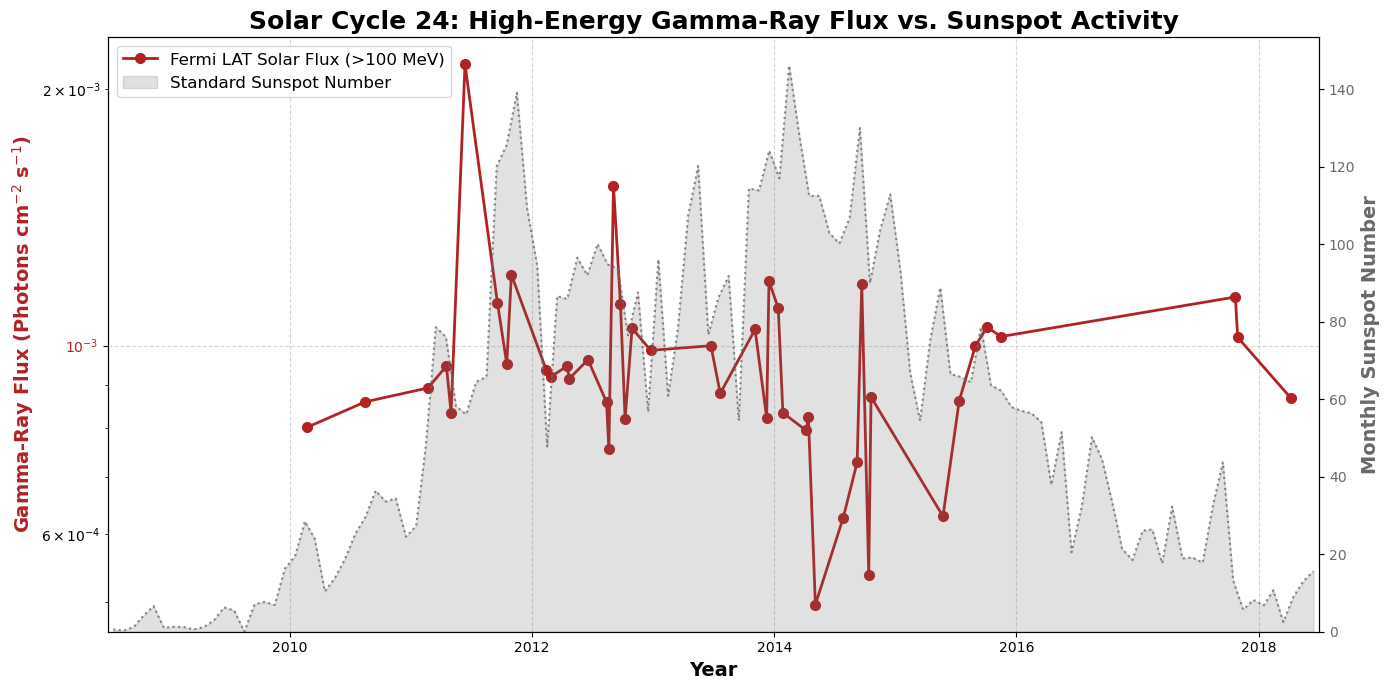

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Load the data
df = pd.read_csv('solar_cycle_flux.csv')
df = df.sort_values('week')

#Convert Fermi Week to Calendar Year (Week 1 = Aug 2008)
df['year'] = 2008.59 + (df['week'] - 1) * (7 / 365.25)

#get the sunspot data from SIDC
#SIDC provides a live CSV of historical monthly sunspot numbers
url = 'https://www.sidc.be/SILSO/DATA/SN_m_tot_V2.0.csv'
# Columns: Year, Month, DecimalYear, SunspotNumber, StdDev, Obs, Marker
sunspots = pd.read_csv(url, sep=';', header=None, 
                       names=['Y', 'M', 'DecimalYear', 'SSN', 'StdDev', 'Obs', 'Def'])

# Filter for the Fermi Era (2008 to 2018)
sunspots = sunspots[(sunspots['DecimalYear'] >= 2008.5) & (sunspots['DecimalYear'] <= 2018.5)]


fig, ax1 = plt.subplots(figsize=(14, 7))

#left axis for gamma-ray flux
color1 = 'firebrick'
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
ax1.set_ylabel('Gamma-Ray Flux (Photons cm$^{-2}$ s$^{-1}$)', color=color1, fontsize=14, fontweight='bold')
ax1.plot(df['year'], df['flux'], color=color1, marker='o', linestyle='-', linewidth=2, markersize=7, label='Fermi LAT Solar Flux (>100 MeV)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_yscale('log')
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

#right axis for sunspot number
ax2 = ax1.twinx()
color2 = 'dimgrey'
ax2.set_ylabel('Monthly Sunspot Number', color=color2, fontsize=14, fontweight='bold')
ax2.fill_between(sunspots['DecimalYear'], 0, sunspots['SSN'], color=color2, alpha=0.2, label='Standard Sunspot Number')
ax2.plot(sunspots['DecimalYear'], sunspots['SSN'], color=color2, linestyle=':', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(bottom=0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=12)

plt.title('Solar Cycle 24: High-Energy Gamma-Ray Flux vs. Sunspot Activity', fontsize=18, fontweight='bold')
plt.xlim(2008.5, 2018.5)
plt.tight_layout()

#Save the final figure
plt.savefig('Solar_Cycle_24_Final.png', dpi=300)
plt.show()